In [6]:
# 1. Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [14]:
# 2. Load Dataset

file_path1 = r"C:\Users\nisha\Downloads\Titanic Dataset file\train.csv"

file_path2 = r"C:\Users\nisha\Downloads\Titanic Dataset file\gender_submission.csv"

file_path3 = r"C:\Users\nisha\Downloads\Titanic Dataset file\test.csv"

df = pd.read_csv(file_path1)


# Display first 5 rows
print("First 5 Rows:")
print(df.head())


First 5 Rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN

In [15]:
df1 = pd.read_csv(file_path2)

df2 = pd.read_csv(file_path3)
print("First 5 Rows:")
print(df1.head())

print("First 5 Rows:")
print(df2.head())

First 5 Rows:
   PassengerId  Survived
0          892         0
1          893         1
2          894         0
3          895         0
4          896         1
First 5 Rows:
   PassengerId  Pclass                                          Name     Sex  \
0          892       3                              Kelly, Mr. James    male   
1          893       3              Wilkes, Mrs. James (Ellen Needs)  female   
2          894       2                     Myles, Mr. Thomas Francis    male   
3          895       3                              Wirz, Mr. Albert    male   
4          896       3  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female   

    Age  SibSp  Parch   Ticket     Fare Cabin Embarked  
0  34.5      0      0   330911   7.8292   NaN        Q  
1  47.0      1      0   363272   7.0000   NaN        S  
2  62.0      0      0   240276   9.6875   NaN        Q  
3  27.0      0      0   315154   8.6625   NaN        S  
4  22.0      1      1  3101298  12.2875   NaN        S  

In [21]:
# 3. Data Cleaning

print("\nMissing Values:")
print(df.isnull().sum())

print("\nMissing Values:")
print(df1.isnull().sum())

print("\nMissing Values:")
print(df2.isnull().sum())

# Fill missing Age with median
df["Age"].fillna(df["Age"].median(), inplace=True)

# Fill missing Age with median
#df1["Age"].fillna(df["Age"].median(), inplace=True)

# Fill missing Age with median
df2["Age"].fillna(df["Age"].median(), inplace=True)


# Fill missing Embarked with most frequent value
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

# Fill missing Embarked with most frequent value
#df1["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

# Fill missing Embarked with most frequent value
df2["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

# Drop Cabin column (too many missing values)
#df.drop("Cabin", axis=1, inplace=True)

# Drop Cabin column (too many missing values)
#df1.drop("Cabin", axis=1, inplace=True)

# Drop Cabin column (too many missing values)
df2.drop("Cabin", axis=1, inplace=True)


print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

print("\nMissing Values After Cleaning:")
print(df1.isnull().sum())

print("\nMissing Values After Cleaning:")
print(df2.isnull().sum())


Missing Values:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Missing Values:
PassengerId    0
Survived       0
dtype: int64

Missing Values:
PassengerId      0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

Missing Values After Cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Missing Values After Cleaning:
PassengerId    0
Survived       0
dtype: int64

Missing Values After Cleaning:
PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
F

C:\Users\nisha\AppData\Local\Temp\ipykernel_15412\1948133706.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)
C:\Users\nisha\AppData\Local\Temp\ipykernel_15412\1948133706.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For

In [27]:
# 4. Analysis Questions

# Q1: Who survived more - male or female?
survival_gender = df.groupby("Sex")["Survived"].mean()
print("\nSurvival Rate by Gender:")
print(survival_gender)

# Q2: Did passenger class affect survival?
survival_class = df.groupby("Pclass")["Survived"].mean()
print("\nSurvival Rate by Class:")
print(survival_class)

# Q3: Survival rate by age group
# Create Age Groups
bins = [0, 12, 18, 35, 60, 100]
labels = ["Child", "Teen", "Young Adult", "Adult", "Senior"]

df["AgeGroup"] = pd.cut(df["Age"], bins=bins, labels=labels)

survival_age = df.groupby("AgeGroup")["Survived"].mean()
print("\nSurvival Rate by Age Group:")
print(survival_age)


Survival Rate by Gender:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Survival Rate by Class:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

Survival Rate by Age Group:
AgeGroup
Child          0.579710
Teen           0.428571
Young Adult    0.353271
Adult          0.400000
Senior         0.227273
Name: Survived, dtype: float64


C:\Users\nisha\AppData\Local\Temp\ipykernel_15412\1570898389.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_age = df.groupby("AgeGroup")["Survived"].mean()


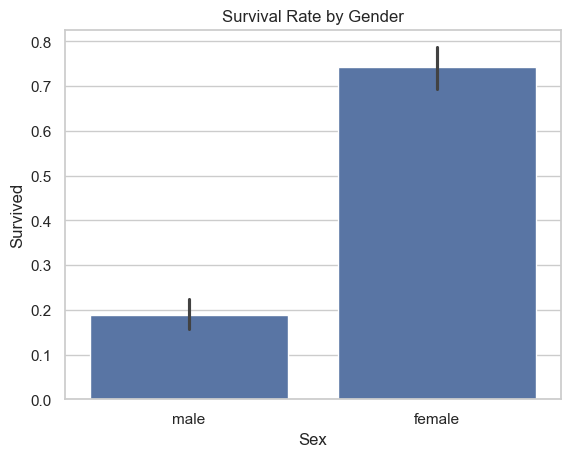

In [23]:
# 5. Visualizations

# Bar chart - Survival by Gender
plt.figure()
sns.barplot(x="Sex", y="Survived", data=df)
plt.title("Survival Rate by Gender")
plt.show()



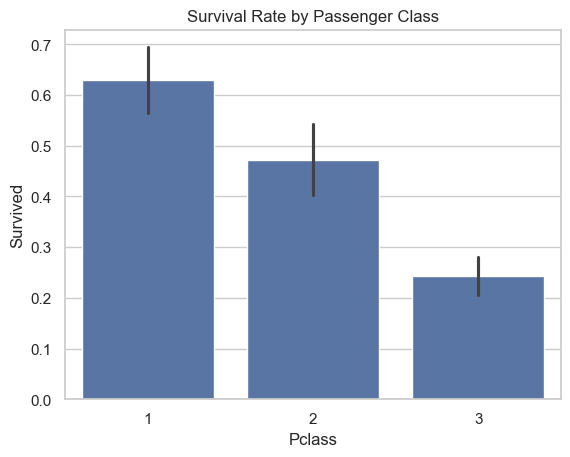

In [24]:

# Bar chart - Survival by Class
plt.figure()
sns.barplot(x="Pclass", y="Survived", data=df)
plt.title("Survival Rate by Passenger Class")
plt.show()

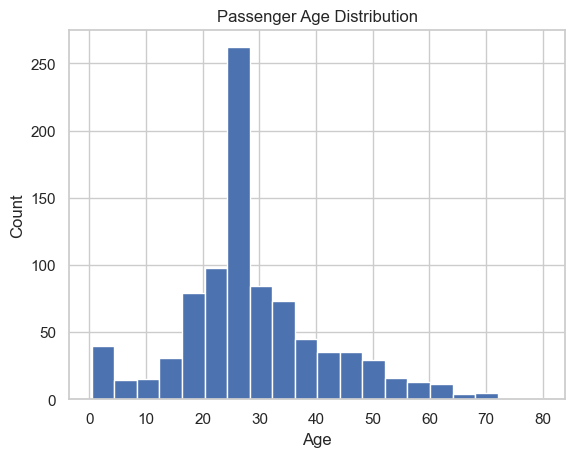

In [25]:
# Histogram - Passenger Age Distribution
plt.figure()
plt.hist(df["Age"], bins=20)
plt.title("Passenger Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()